<a href="https://colab.research.google.com/github/jooyoung227/ESAA-14-23-/blob/main/ESAA_jooyoung_YB_0522_session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 데이터 로드
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784', version=1)

In [2]:
# train, test split
X_train = mnist['data'][:60000]
y_train = mnist['target'][:60000]
X_test = mnist['data'][60000:]
y_test = mnist['target'][60000:]

* 랜덤포레스트에 적용

In [5]:
# 랜덤포레스트에 적용 (n_estimators=10, random_state=42)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_clf = RandomForestClassifier(n_estimators=10, random_state=42)
rf_clf.fit(X_train, y_train)

pred = rf_clf.predict(X_test)

In [6]:
# 정확도 결과
accuracy_score(y_test, pred)

0.9492

# 1. PCA

* PCA로 변환한 데이터 세트에 랜덤 포레스트 적용

In [4]:
# PCA 라이브러리 불러오기
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [7]:
# PCA 적용 95% : n_components=0.95
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(X_train_pca.shape)
print(X_test_pca.shape)

(60000, 154)
(10000, 154)


In [8]:
# PCA 이후 랜덤포레스트 훈련
rf_clf_pca = RandomForestClassifier(n_estimators=10, random_state=42)
rf_clf_pca.fit(X_train_pca, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [9]:
# 정확도 결과 (X_test도 PCA 적용해야합니다.)
pred_pca = rf_clf_pca.predict(X_test_pca)

print('PCA 적용 후 정확도:', accuracy_score(y_test, pred_pca))

PCA 적용 후 정확도: 0.8925


**관련 문제**

* PCA모델을 와인 데이터셋에 적용하여 차원을 축소하고 그 결과를 그래프로 나타내보세요.

(1) 필요한 모듈 불러오기

In [10]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

(2)  load_wine을 사용해 데이터셋을 생성한다.

In [11]:
wine = load_wine()

X = wine.data
y = wine.target

wineDF = pd.DataFrame(X, columns=wine.feature_names)
wineDF['target'] = y

wineDF.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


(3) X에 표준 스케일링(Standard scaling)을 적용하여 X_scaled을 생성한다.

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

(4) PCA 모델을 X에 적용하여 2개의 차원으로 추출한다. 단, random_state=1234로 설정한다.

In [13]:
#PCA 모델을 X_scaled에 적용하여 2개의 차원으로 추출한다.
pca = PCA(n_components=2, random_state=1234)

X_pca = pca.fit_transform(X_scaled)

pcaDF = pd.DataFrame(X_pca, columns=['pca_component_1', 'pca_component_2'])
pcaDF['target'] = y

pcaDF.head()

,pca_component_1,pca_component_2,target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


(5) 추출한 피처를 그래프로 나타내라.

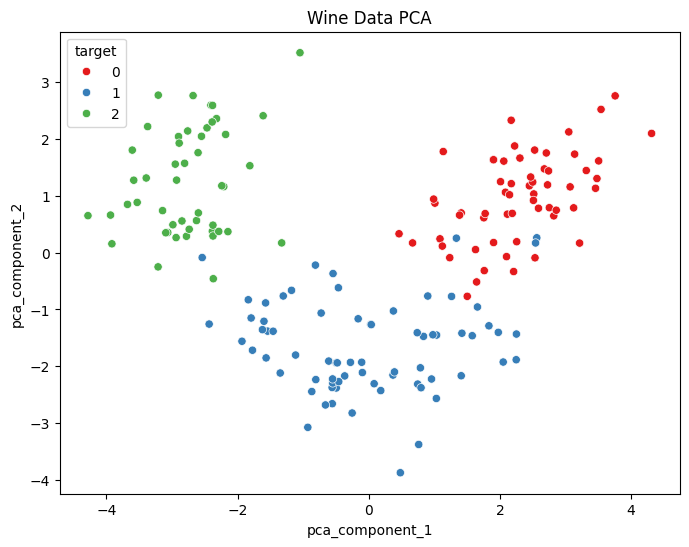

In [14]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='pca_component_1',
    y='pca_component_2',
    hue='target',
    data=pcaDF,
    palette='Set1'
)

plt.title('Wine Data PCA')
plt.xlabel('pca_component_1')
plt.ylabel('pca_component_2')
plt.show()

# 2. LDA

- LDA로 변환한 데이터 세트에 랜덤 포레스트 적용

In [15]:
# LDA 라이브러리 불러오기
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [16]:
# LDA 적용 : n_components=5
lda = LinearDiscriminantAnalysis(n_components=5)

X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

print(X_train_lda.shape)
print(X_test_lda.shape)

(60000, 5)
(10000, 5)


In [17]:
# LDA 이후 랜덤포레스트 훈련
rf_clf_lda = RandomForestClassifier(n_estimators=10, random_state=42)
rf_clf_lda.fit(X_train_lda, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [18]:
# 정확도 결과 (X_test도 LDA 적용해야합니다.)
pred_lda = rf_clf_lda.predict(X_test_lda)

print('LDA 적용 후 정확도:', accuracy_score(y_test, pred_lda))

LDA 적용 후 정확도: 0.8301
